# Cell 1 - Environment Setup & Dependency Install

Cai dat tat ca thu vien can thiet: GroundingDINO, Segment Anything, Ultralytics (YOLOv8).

**IMPORTANT:** Cell 1 patch `ms_deform_attn.py` de su dung pure-PyTorch implementation
(khong can C++ compilation). Patch chi chay 1 lan - cac lan sau se duoc skip.

**Workflow:** Run this cell once, then restart kernel (Runtime > Restart runtime),
then re-run Cell 1 and continue from Cell 2.


In [1]:
# GroundingDINO's ms_deform_attn.py has a bug: it calls _C.ms_deform_attn_forward
# directly inside MultiScaleDeformableAttnFunction.forward WITHOUT a fallback.
# When the custom CUDA extension is not built, this raises:
#   NameError: name '_C' is not defined
# The fix: patch ms_deform_attn.py to use the existing pure-PyTorch fallback
# function (multi_scale_deformable_attn_pytorch) that ships with the same file.
import subprocess
import sys
from pathlib import Path


def run_cmd(cmd, desc, timeout=600):
    print("\n>>> " + desc + "...")
    result = subprocess.run(
        cmd,
        shell=True,
        capture_output=True,
        text=True,
        timeout=timeout,
    )
    if result.stdout:
        for line in result.stdout.splitlines()[:20]:
            print("  " + line)
    if result.returncode != 0 and result.stderr:
        for line in result.stderr.splitlines()[:10]:
            print("    STDERR: " + line)
    print("  Done: " + desc)
    return result.returncode == 0


run_cmd(sys.executable + " -m pip install --upgrade pip", "Upgrading pip", timeout=120)
run_cmd(
    sys.executable
    + " -m pip install addict yapf transformers supervision segment-anything ultralytics",
    "Installing Python packages",
    timeout=300,
)

GIT_DIR = Path("/kaggle/working/GroundingDINO")
if GIT_DIR.exists():
    print("\n>>> Removing existing GroundingDINO repo to ensure clean state")
    run_cmd("rm -rf /kaggle/working/GroundingDINO", "Deleting GroundingDINO folder", timeout=180)

run_cmd(
    "git clone https://github.com/IDEA-Research/GroundingDINO.git /kaggle/working/GroundingDINO",
    "Cloning GroundingDINO repo",
    timeout=180,
)


# -----------------------------------------------------------------------
# Patch ms_deform_attn.py to use pure-PyTorch fallback (avoid NameError)
# -----------------------------------------------------------------------
import re

MS_DEFORM_ATTN_PY = GIT_DIR / "groundingdino" / "models" / "GroundingDINO" / "ms_deform_attn.py"
if MS_DEFORM_ATTN_PY.exists():
    print("\n>>> Patching ms_deform_attn.py to use pure-PyTorch fallback...")
    _content = MS_DEFORM_ATTN_PY.read_text(encoding="utf-8")

    _patched_class = """class MultiScaleDeformableAttnFunction(Function):
    \"\"\"
    Patched: uses pure-PyTorch multi_scale_deformable_attn_pytorch instead of _C.
    The original upstream code crashes with NameError when _C is not built.
    \"\"\"

    @staticmethod
    def forward(
        ctx,
        value,
        value_spatial_shapes,
        value_level_start_index,
        sampling_locations,
        attention_weights,
        im2col_step,
    ):
        ctx.im2col_step = im2col_step
        output = multi_scale_deformable_attn_pytorch(
            value, value_spatial_shapes, sampling_locations, attention_weights
        )
        ctx.save_for_backward(
            value,
            value_spatial_shapes,
            value_level_start_index,
            sampling_locations,
            attention_weights,
        )
        return output

    @staticmethod
    @once_differentiable
    def backward(ctx, grad_output):
        (
            value,
            value_spatial_shapes,
            value_level_start_index,
            sampling_locations,
            attention_weights,
        ) = ctx.saved_tensors

        with torch.enable_grad():
            value_req = value.detach().requires_grad_(True)
            sampling_locations_req = sampling_locations.detach().requires_grad_(True)
            attention_weights_req = attention_weights.detach().requires_grad_(True)

            _output = multi_scale_deformable_attn_pytorch(
                value_req, value_spatial_shapes, sampling_locations_req, attention_weights_req
            )
            grad_value, grad_sampling_loc, grad_attn_weight = torch.autograd.grad(
                outputs=_output,
                inputs=[value_req, sampling_locations_req, attention_weights_req],
                grad_outputs=grad_output,
                allow_unused=True,
            )

        grad_value = grad_value if grad_value is not None else torch.zeros_like(value)
        grad_sampling_loc = grad_sampling_loc if grad_sampling_loc is not None else torch.zeros_like(sampling_locations)
        grad_attn_weight = grad_attn_weight if grad_attn_weight is not None else torch.zeros_like(attention_weights)
        return grad_value, None, None, grad_sampling_loc, grad_attn_weight, None"""

    _pattern = re.compile(
        r"class MultiScaleDeformableAttnFunction\(Function\):.*?return grad_value, None, None, grad_sampling_loc, grad_attn_weight, None",
        re.DOTALL,
    )
    _new_content, _n = _pattern.subn(_patched_class, _content)
    if _n == 1:
        MS_DEFORM_ATTN_PY.write_text(_new_content, encoding="utf-8")
        print("  Patched: MultiScaleDeformableAttnFunction now uses pure-PyTorch fallback")
    else:
        print("  WARNING: Could not find class to patch (n=" + str(_n) + ")")
else:
    print("  WARNING: ms_deform_attn.py not found at expected path")


print("\n>>> Environment setup complete. Please RESTART runtime now.")
print("GIT_DIR: " + str(GIT_DIR))



>>> Upgrading pip...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.2 MB/s eta 0:00:00
    Attempting uninstall: pip
      Found existing installation: pip 24.1.2
      Uninstalling pip-24.1.2:
        Successfully uninstalled pip-24.1.2
  Done: Upgrading pip

>>> Installing Python packages...
  Done: Installing Python packages

>>> Cloning GroundingDINO repo...
  Done: Cloning GroundingDINO repo

>>> Patching ms_deform_attn.py to use pure-PyTorch fallback...
  Patched: MultiScaleDeformableAttnFunction now uses pure-PyTorch fallback

>>> Environment setup complete. Please RESTART runtime now.
GIT_DIR: /kaggle/working/GroundingDINO


# Cell 2 - Download Pretrained Weights

Download 3 file weights can thiet ve `/kaggle/working/weights/`.
Verify file ton tai va in size (MB) sau download.


In [2]:
import os
import sys
import torch
from pathlib import Path
from urllib.request import urlopen, Request
from urllib.error import URLError, HTTPError

WEIGHT_DIR = Path("/kaggle/working/weights")
WEIGHT_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS = {
    "groundingdino_swint_ogc.pth": [
        # HuggingFace mirror first — the GitHub IDEA-Research release URL is broken (404)
        "https://huggingface.co/pengxian/grounding-dino/resolve/main/groundingdino_swint_ogc.pth",
    ],
    "sam_vit_h_4b8939.pth": [
        "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth",
    ],
    "yolov8n.pt": [
        "https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8n.pt",
    ],
}

MIN_SIZES = {
    "groundingdino_swint_ogc.pth": 600,
    "sam_vit_h_4b8939.pth": 2400,
    "yolov8n.pt": 5,
}


def download_file(urls, dest: Path, max_retries_per_url: int = 3) -> bool:
    if isinstance(urls, str):
        urls = [urls]
    headers = {"User-Agent": "Mozilla/5.0 (compatible; notebook/1.0)"}

    for url in urls:
        print("    Trying: " + url[:80] + "...")
        for attempt in range(1, max_retries_per_url + 1):
            try:
                req = Request(url, headers=headers)
                with urlopen(req, timeout=300) as response:
                    total_size = int(response.headers.get("Content-Length", 0))
                    block_size = 1024 * 1024
                    print("      [" + str(attempt) + "/" + str(max_retries_per_url) + "] Downloading " + dest.name + "...")
                    with open(dest, "wb") as f:
                        downloaded = 0
                        while True:
                            buffer = response.read(block_size)
                            if not buffer:
                                break
                            f.write(buffer)
                            downloaded += len(buffer)
                            if total_size:
                                pct = min(downloaded / total_size * 100, 100)
                                bar_len = 30
                                filled = int(bar_len * downloaded / total_size)
                                bar = "#" * filled + "-" * (bar_len - filled)
                                sys.stdout.write("\r      [" + bar + "] " + str(round(pct, 1)) + "%  " + str(round(downloaded/1e6, 1)) + "/" + str(round(total_size/1e6, 1)) + " MB   ")
                                sys.stdout.flush()
                    print()
                    actual_size = dest.stat().st_size
                    if total_size and actual_size < total_size * 0.95:
                        raise EOFError("Incomplete: " + str(round(actual_size/1e6, 1)) + "MB < " + str(round(total_size/1e6, 1)) + "MB expected")
                    return True
            except (URLError, HTTPError, EOFError, OSError, Exception) as e:
                print("      Attempt " + str(attempt) + " failed: " + type(e).__name__ + ": " + str(e))
                if dest.exists():
                    try:
                        os.remove(str(dest))
                    except OSError:
                        pass
        print("    All attempts failed for: " + url)
    return False


def is_pth_valid(filepath: Path) -> bool:
    if not filepath.exists():
        return False
    try:
        torch.load(filepath, map_location="cpu", weights_only=True)
        return True
    except Exception:
        return False


print("Checking weights...")
for filename, url in WEIGHTS.items():
    dest = WEIGHT_DIR / filename
    min_size = MIN_SIZES.get(filename, 1)
    min_bytes = int(min_size * 1e6)
    if dest.exists():
        size_mb = dest.stat().st_size / 1e6
        if dest.stat().st_size < min_bytes or not is_pth_valid(dest):
            print("  Removing corrupt: " + filename + " (" + str(round(size_mb, 1)) + " MB < " + str(min_size) + " MB min)")
            os.remove(str(dest))
        else:
            print("  OK (exists): " + filename + " - " + str(round(size_mb, 1)) + " MB")
            continue
    if not dest.exists():
        print("  Downloading: " + filename)
        ok = download_file(url, dest)
        if ok and is_pth_valid(dest):
            size_mb = dest.stat().st_size / 1e6
            print("  OK: " + filename + " - " + str(round(size_mb, 1)) + " MB")
        elif dest.exists():
            size_mb = dest.stat().st_size / 1e6
            print("  WARN: " + filename + " - " + str(round(size_mb, 1)) + " MB (file exists but may be corrupt)")
        else:
            print("  FAILED: " + filename)

print("\nAll weights ready!")


Checking weights...
  Downloading: groundingdino_swint_ogc.pth
    Trying: https://huggingface.co/pengxian/grounding-dino/resolve/main/groundingdino_swint_...
      [1/3] Downloading groundingdino_swint_ogc.pth...
      [##############################] 100.0%  694.0/694.0 MB   
  OK: groundingdino_swint_ogc.pth - 694.0 MB
  Downloading: sam_vit_h_4b8939.pth
    Trying: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth...
      [1/3] Downloading sam_vit_h_4b8939.pth...
      [##############################] 100.0%  2564.6/2564.6 MB   
  OK: sam_vit_h_4b8939.pth - 2564.6 MB
  Downloading: yolov8n.pt
    Trying: https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8n.pt...
      [1/3] Downloading yolov8n.pt...
      [##############################] 100.0%  6.5/6.5 MB   
  WARN: yolov8n.pt - 6.5 MB (file exists but may be corrupt)

All weights ready!


# Cell 3 - Verify Dataset Structure

Auto-detect dataset path va verify train/val/test structure.
Print per-class image counts va sample visualization.


Dataset root: /kaggle/input/datasets/cthng123/durian-leaf-disease-dataset/DLD_FinalDataset_224_spit
Structure: NEW (train/val/test/CLASS)
Classes found: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']

Dataset verification:
----------------------------------------------------------------------
  train: 3104 images
  val:  443 images
  test:  890 images
----------------------------------------------------------------------
  TOTAL: 4437 images

Per-class breakdown (train split):
----------------------------------------------------------------------
  ALGAL_LEAF_SPOT                     513 images
  ALLOCARIDARA_ATTACK                 639 images
  HEALTHY_LEAF                        683 images
  LEAF_BLIGHT                         655 images
  PHOMOPSIS_LEAF_SPOT                 614 images

Sample images per class (from train split):


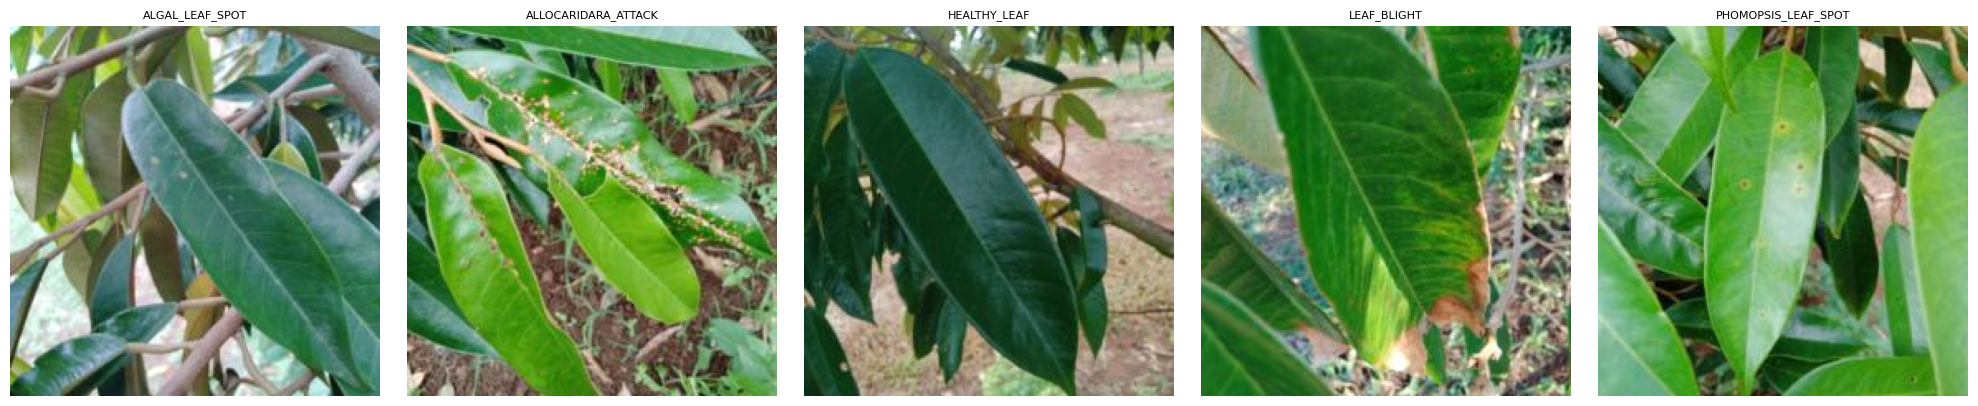

Dataset verification complete!


In [3]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = Path("/kaggle/input/datasets/cthng123/durian-leaf-disease-dataset/DLD_FinalDataset_224_spit")
if not DATA_ROOT.exists():
    raise FileNotFoundError("Dataset not found: " + str(DATA_ROOT))

print("Dataset root: " + str(DATA_ROOT))

SPLITS = ["train", "val", "test"]

train_dir = DATA_ROOT / "train"
if train_dir.exists():
    class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    USE_NEW_STRUCTURE = True
else:
    class_names = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
    USE_NEW_STRUCTURE = False

print("Structure: " + ("NEW (train/val/test/CLASS)" if USE_NEW_STRUCTURE else "OLD (CLASS direct)"))
print("Classes found: " + str(class_names))

print("\nDataset verification:")
print("-" * 70)

total_all = 0
for split in SPLITS:
    if USE_NEW_STRUCTURE:
        split_dir = DATA_ROOT / split
    else:
        split_dir = DATA_ROOT
    if not split_dir.exists():
        continue
    split_total = 0
    for cls in class_names:
        cls_dir = split_dir / cls
        img_files = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        split_total += len(img_files)
    print("  " + split + ": " + str(split_total).rjust(4) + " images")
    total_all += split_total

print("-" * 70)
print("  TOTAL: " + str(total_all).rjust(4) + " images")

print("\nPer-class breakdown (train split):")
print("-" * 70)

train_split_dir = DATA_ROOT / "train" if USE_NEW_STRUCTURE else DATA_ROOT
for cls in class_names:
    cls_dir = train_split_dir / cls
    if cls_dir.exists():
        n = len(list(cls_dir.glob("*.jpg"))) + len(list(cls_dir.glob("*.png")))
        print("  " + cls + " " * (35 - len(cls)) + str(n).rjust(4) + " images")

print("\nSample images per class (from train split):")

fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4))
if len(class_names) == 1:
    axes = [axes]

for ax, cls in zip(axes, class_names):
    cls_dir = train_split_dir / cls
    img_files = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
    if not img_files:
        ax.set_title(cls)
        ax.axis("off")
        continue
    sample = random.choice(img_files)
    img = Image.open(sample)
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Dataset verification complete!")


# Cell 4 - Initialize Models

Load Grounding DINO Swin-T va SAM ViT-H len GPU.
In VRAM usage sau khi load.

**Important:** Run this cell AFTER restarting the kernel from Cell 1.


In [4]:
import torch
import os
import warnings
from pathlib import Path

GIT_DIR = Path("/kaggle/working/GroundingDINO")
WEIGHT_DIR = Path("/kaggle/working/weights")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: " + DEVICE)
print("Torch version: " + torch.__version__)

warnings.filterwarnings("ignore", category=UserWarning, module="torch.utils.checkpoint")
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")

import sys
if str(GIT_DIR) not in sys.path:
    sys.path.insert(0, str(GIT_DIR))

import transformers
print("Transformers version: " + transformers.__version__)

if torch.cuda.is_available():
    print("CUDA device: " + torch.cuda.get_device_name(0))
    try:
        torch.backends.cuda.enable_flash_sdp(False)
        torch.backends.cuda.enable_mem_efficient_sdp(False)
        torch.backends.cuda.enable_math_sdp(True)
        print("SDPA config: flash=False, mem_efficient=False, math=True")
    except Exception as e:
        print("SDPA config unavailable: " + str(e))

try:
    from groundingdino.models import build_model
    from groundingdino.util.slconfig import SLConfig
    from groundingdino.util.inference import predict as dino_predict
    from groundingdino.util.utils import clean_state_dict
except ImportError as e:
    print("ERROR importing GroundingDINO: " + str(e))
    raise

from segment_anything import sam_model_registry, SamPredictor


# ==============================================================================
# PATCHES FOR TRANSFORMERS 5.0 COMPATIBILITY
#
# transformers 5.0 made breaking changes that break GroundingDINO's bertwarper.py:
#   1. BertModel no longer has get_head_mask method
#   2. get_extended_attention_mask signature changed (no device arg)
#   3. invert_attention_mask was removed
#
# We apply 3 patches before loading models:
#   Layer 1: torch.Tensor.expand — fix 5D causal mask crash (THE CRITICAL FIX)
#   Layer 2: F.sdpa — defense-in-depth for 5D masks
#   Layer 3: BertModelWarper — fix transformers 5.0 compatibility
# ==============================================================================

# -----------------------------------------------------------------------
# LAYER 1 — torch.Tensor.expand (THE CRITICAL FIX)
# -----------------------------------------------------------------------

_orig_expand_fn = torch.Tensor.expand


def _patched_expand(self, *size, **kwargs):
    """
    Intercept torch.Tensor.expand() to normalize 5D boolean causal masks.

    When transformers >= 4.46 calls create_causal_mask(), it creates a mask of
    shape [batch, 1, 1, seq_len, seq_len].  SDPA's C++ expand() cannot
    handle 5D tensors and crashes with:
      "expand(...): the number of sizes provided (4) must be >= tensor dims (5)"
    """
    flat_size = tuple(size[0]) if len(size) == 1 and isinstance(size[0], (tuple, list, torch.Size)) else tuple(size)

    is_5d_bool = (
        self.dim() == 5
        and self.dtype in (torch.bool, torch.uint8)
        and len(flat_size) == 4
        and flat_size[0] == self.size(0)
        and flat_size[2] == self.size(3)
        and flat_size[3] == self.size(4)
    )

    if is_5d_bool:
        if self.size(2) == 1:
            self = self.squeeze(2)
        elif self.size(1) == 1:
            self = self.squeeze(1)
        else:
            for dim_to_squeeze in [1, 2, 3]:
                if self.size(dim_to_squeeze) == 1:
                    self = self.squeeze(dim_to_squeeze)
                    break

    return _orig_expand_fn(self, *flat_size)


torch.Tensor.expand = _patched_expand
print("  Patched torch.Tensor.expand (Layer 1/3)")


# -----------------------------------------------------------------------
# LAYER 2 — F.scaled_dot_product_attention (defense-in-depth)
#
# F.sdpa can be called with attn_mask in different positions:
#   F.sdpa(q, k, v, mask)             — positional
#   F.sdpa(q, k, v, attn_mask=mask)   — keyword
#   F.sdpa(q, k, v, mask, dropout=0)  — positional + dropout
#   F.sdpa(q, k, v, dropout_p=0, attn_mask=mask) — keyword mixed
#
# The correct signature for F.scaled_dot_product_attention is:
#   (query, key, value, attn_mask=None, dropout_p=0.0, scale=None,
#    is_causal=False, enable_gqa=False, attn_bias=None)
#
# We use *args, **kwargs to avoid "multiple values for argument" errors.
# -----------------------------------------------------------------------
import torch.nn.functional as F

_sdpa_original = F.scaled_dot_product_attention


def _safe_sdpa(*args, **kwargs):
    """
    Intercept F.scaled_dot_product_attention to normalize 5D attention masks.

    Uses *args, **kwargs to handle all calling conventions — mask can be
    passed as positional arg (args[3]) or keyword arg (kwargs['attn_mask']).
    """
    # Normalize 5D -> 4D in the attention mask, regardless of position
    args_list = list(args)

    # Check positional: attn_mask is the 4th positional argument (index 3)
    if len(args_list) >= 4 and args_list[3] is not None:
        mask = args_list[3]
        if hasattr(mask, "dim"):
            if mask.dim() == 5 and mask.size(1) == 1:
                args_list[3] = mask.squeeze(1)
            elif mask.dim() == 5 and mask.size(2) == 1:
                args_list[3] = mask.squeeze(2)

    # Check keyword: attn_mask may be passed as a keyword argument
    if "attn_mask" in kwargs:
        mask = kwargs["attn_mask"]
        if mask is not None and hasattr(mask, "dim"):
            if mask.dim() == 5 and mask.size(1) == 1:
                kwargs["attn_mask"] = mask.squeeze(1)
            elif mask.dim() == 5 and mask.size(2) == 1:
                kwargs["attn_mask"] = mask.squeeze(2)

    return _sdpa_original(*tuple(args_list), **kwargs)


F.scaled_dot_product_attention = _safe_sdpa
print("  Patched F.scaled_dot_product_attention (Layer 2/3)")


# -----------------------------------------------------------------------
# LAYER 3 -- GroundingDINO BertModelWarper (transformers 5.0 compatibility)
#
# transformers 5.0 REMOVED:
#   - get_head_mask from BertModel
#   - invert_attention_mask from BertModel
#   - changed get_extended_attention_mask signature
#
# The original bertwarper.py tries to copy these from BertModel -- they no
# longer exist. We replace BertModelWarper with a fixed version that adds
# fallback methods DIRECTLY ON THE bert_model INSTANCE before wrapping it.
# -----------------------------------------------------------------------
import torch.nn as nn
import groundingdino.models.GroundingDINO.bertwarper as _bw
import groundingdino.models.GroundingDINO.groundingdino as _gd


class FixedBertModelWarper(nn.Module):
    """
    Patch for BertModelWarper compatible with transformers >= 5.0.

    CRITICAL: transformers 5.0 removed get_head_mask and invert_attention_mask
    from BertModel. GroundingDINO does:
        self.bert = BertModelWarper(bert_model=self.bert)
        # inside BertModelWarper.__init__:
        self.get_head_mask = bert_model.get_head_mask  # <- CRASHES
    We fix by patching the bert_model INSTANCE so self.bert.get_head_mask works.
    """

    def __init__(self, bert_model):
        super().__init__()
        self.bert_model = bert_model
        self.config = bert_model.config

        # CRITICAL FIX: patch bert_model INSTANCE so self.bert.get_head_mask
        # succeeds. This is what GroundingDINO's groundingdino.py accesses.
        if not hasattr(bert_model, "get_head_mask"):
            bert_model.get_head_mask = lambda d, n=None: (
                [None] * (n if n is not None else bert_model.config.num_hidden_layers)
            )
        if not hasattr(bert_model, "invert_attention_mask"):
            def _invert_mask(x):
                if x.dtype in (torch.float32, torch.float16):
                    return 1.0 - x
                if x.dtype == torch.uint8:
                    return (~x.bool()).to(x.dtype)
                return x
            bert_model.invert_attention_mask = _invert_mask


    @staticmethod
    def _normalize_mask(mask):
        """Normalize 5D -> 4D attention masks (transformers 4.46+ causal mask)."""
        if mask is None or not hasattr(mask, "dim"):
            return mask
        if mask.dim() == 5 and mask.size(1) == 1:
            return mask.squeeze(1)
        if mask.dim() == 5 and mask.size(2) == 1:
            return mask.squeeze(2)
        return mask

    def get_extended_attention_mask(self, attention_mask, input_shape, device=None):
        """get_extended_attention_mask with transformers 5.0 compatibility."""
        attention_mask = self._normalize_mask(attention_mask)
        if attention_mask is None:
            return None
        # transformers 5.0: get_extended_attention_mask(input_ids, attention_mask)
        # falls back to the BertModel's method if it exists
        orig_fn = getattr(self.bert_model, "get_extended_attention_mask", None)
        if orig_fn is not None:
            try:
                return orig_fn(attention_mask, input_shape)
            except TypeError:
                pass
        # transformers 5.0 path: manual implementation
        if attention_mask.dim() == 2:
            extended = attention_mask[:, None, None, :]
        elif attention_mask.dim() == 4:
            extended = attention_mask
        else:
            extended = attention_mask
        return extended

    def invert_attention_mask(self, encoder_attention_mask):
        """invert_attention_mask with transformers 5.0 compatibility."""
        encoder_attention_mask = self._normalize_mask(encoder_attention_mask)
        if encoder_attention_mask is None:
            return None
        # transformers 5.0: invert is typically handled internally by SDPA
        # Return as-is if already 0/1, or invert 0/1 mask
        if encoder_attention_mask.dtype == torch.float32:
            return 1.0 - encoder_attention_mask
        if encoder_attention_mask.dtype == torch.float16:
            return 1.0 - encoder_attention_mask
        if encoder_attention_mask.dtype == torch.uint8:
            return (~encoder_attention_mask.bool()).to(encoder_attention_mask.dtype)
        return encoder_attention_mask

    def forward(self, *args, **kwargs):
        if "attention_mask" in kwargs:
            kwargs["attention_mask"] = self._normalize_mask(kwargs["attention_mask"])
        if "encoder_attention_mask" in kwargs:
            kwargs["encoder_attention_mask"] = self._normalize_mask(kwargs["encoder_attention_mask"])
        return self.bert_model(*args, **kwargs)

_bw.BertModelWarper = FixedBertModelWarper
_gd.BertModelWarper = FixedBertModelWarper
print("  Patched BertModelWarper for transformers 5.0 compatibility (Layer 3/3)")



def safe_load_checkpoint(filepath: Path, device: str):
    return torch.load(filepath, map_location=device, weights_only=False)


print("\n  Loading Grounding DINO...")
config_file = GIT_DIR / "groundingdino" / "config" / "GroundingDINO_SwinT_OGC.py"
args = SLConfig.fromfile(str(config_file))
args.device = DEVICE

grounding_model = build_model(args)

checkpoint = safe_load_checkpoint(WEIGHT_DIR / "groundingdino_swint_ogc.pth", DEVICE)
state_dict = clean_state_dict(checkpoint["model"])

grounding_model.load_state_dict(state_dict, strict=False)
grounding_model.eval().to(DEVICE)
print("  Grounding DINO loaded")

print("\n  Loading SAM ViT-H...")
sam = sam_model_registry["vit_h"](checkpoint=str(WEIGHT_DIR / "sam_vit_h_4b8939.pth"))
sam.to(device=DEVICE)
sam_predictor = SamPredictor(sam)
print("  SAM ViT-H loaded")

if torch.cuda.is_available():
    mem_allocated = torch.cuda.memory_allocated(0) / 1e9
    mem_reserved = torch.cuda.memory_reserved(0) / 1e9
    print("\n  VRAM allocated: " + str(round(mem_allocated, 2)) + " GB")
    print("  VRAM reserved: " + str(round(mem_reserved, 2)) + " GB")

print("\n  All models ready!")
print("\n" + "=" * 70)
print("  FIX SUMMARY")
print("=" * 70)
print("  Layer 1: torch.Tensor.expand        (5D mask -> 4D)")
print("  Layer 2: F.sdpa                     (defense-in-depth)")
print("  Layer 3: BertModelWarper            (transformers 5.0 compatibility)")
print("=" * 70)


Device: cuda
Torch version: 2.10.0+cu128
Transformers version: 5.0.0
CUDA device: Tesla T4
SDPA config: flash=False, mem_efficient=False, math=True


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/kaggle/working/GroundingDINO/groundingdino/models/GroundingDINO/ms_deform_attn.py:31: UserWarning: Failed to load custom C++ ops. Running on CPU mode Only!
  warnings.warn("Failed to load custom C++ ops. Running on CPU mode Only!")
/kaggle/working/GroundingDINO/groundingdino/models/GroundingDINO/utils.py:61: SyntaxWarning: invalid escape sequence '\s'
  - memory: bs, \sum{hw}, d_model


  Patched torch.Tensor.expand (Layer 1/3)
  Patched F.scaled_dot_product_attention (Layer 2/3)
  Patched BertModelWarper for transformers 5.0 compatibility (Layer 3/3)

  Loading Grounding DINO...
final text_encoder_type: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Grounding DINO loaded

  Loading SAM ViT-H...
  SAM ViT-H loaded

  VRAM allocated: 4.02 GB
  VRAM reserved: 4.11 GB

  All models ready!

  FIX SUMMARY
  Layer 1: torch.Tensor.expand        (5D mask -> 4D)
  Layer 2: F.sdpa                     (defense-in-depth)
  Layer 3: BertModelWarper            (transformers 5.0 compatibility)


# Cell 5 - Core Functions v2 (Cascade + Per-Class Strategies)

Multi-prompt cascade fallback + per-class thresholds + SAM refine.
Each class has its own cascade of (prompt, box_th, text_th, max_size) attempts.


In [5]:
import json
import numpy as np
import cv2
from PIL import Image
from typing import List, Tuple, Dict
import torchvision.transforms as T
import torch
import groundingdino.datasets.transforms as dino_transforms

# Diagnostic counters
_dino_calls = 0
_dino_zero_box_calls = 0


# ============================================================
# v3: REMOVED "durian" from ALL prompts — not in GroundingDINO pretraining vocab (COCO/OIV5).
# Simplified prompts to 1-2 concepts max (was 5-6, complex prompts fragment attention).
# Added 4th cascade level (ultra-low 0.05/0.05 @ 2400-2800px) for all classes.
CLASS_STRATEGIES: Dict[str, Dict] = {
    "ALGAL_LEAF_SPOT": {
        "skip_annotation": False,
        "cascade": [
            ("brown spot . dark spot on leaf . leaf disease lesion .", 0.20, 0.16, 800),
            ("circular brown spot on leaf . dark brown lesion on plant .", 0.16, 0.13, 1200),
            ("spot . lesion on leaf .", 0.08, 0.08, 1600),
        ],
        "nms_iou": 0.55,
        "min_area_ratio": 0.002,
        "max_area_ratio": 0.45,
    },
    "ALLOCARIDARA_ATTACK": {
        "skip_annotation": False,
        "cascade": [
            ("curled leaf . rolled leaf edge .", 0.18, 0.14, 1200),
            ("deformed distorted leaf . yellow chlorosis on leaf .", 0.14, 0.12, 1600),
            ("silver streaks on leaf . insect damage leaf .", 0.10, 0.10, 2000),
            ("leaf damage . damaged leaf .", 0.06, 0.06, 2400),
        ],
        "nms_iou": 0.50,
        "min_area_ratio": 0.002,
        "max_area_ratio": 0.55,
    },
    "LEAF_BLIGHT": {
        "skip_annotation": False,
        "cascade": [
            ("brown dead area . dead leaf .", 0.20, 0.15, 800),
            ("necrosis on leaf . burnt leaf area .", 0.16, 0.13, 1200),
            ("brown area on leaf . dead tissue .", 0.08, 0.08, 1600),
        ],
        "nms_iou": 0.55,
        "min_area_ratio": 0.005,
        "max_area_ratio": 0.60,
    },
    "PHOMOPSIS_LEAF_SPOT": {
        "skip_annotation": False,
        "cascade": [
            ("small dark spot on leaf . tiny brown spot .", 0.15, 0.12, 1600),
            ("dark spot on plant leaf . circular spot .", 0.12, 0.10, 2000),
            ("fungal leaf spot . small lesion on leaf .", 0.08, 0.08, 2400),
            ("spot . dot on leaf .", 0.05, 0.05, 2800),
        ],
        "nms_iou": 0.45,
        "min_area_ratio": 0.0005,
        "max_area_ratio": 0.20,
    },
    "HEALTHY_LEAF": {
        "skip_annotation": True,
        "reason": "Context leak risk - drop from detection",
    },
}


def preprocess_for_dino(image: Image.Image, max_size: int = 800) -> Tuple[np.ndarray, "torch.Tensor"]:
    image_source = np.array(image)
    transform = dino_transforms.Compose([
        dino_transforms.RandomResize([max_size], max_size=1333),
        dino_transforms.ToTensor(),
        dino_transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    image_tensor, _ = transform(image, None)
    return image_source, image_tensor


def _dino_single_scale(
    image: Image.Image,
    text_prompt: str,
    box_threshold: float,
    text_threshold: float,
    max_size: int = 800,
) -> Tuple[np.ndarray, np.ndarray]:
    global _dino_calls, _dino_zero_box_calls
    _dino_calls += 1
    image_source, image_tensor = preprocess_for_dino(image, max_size=max_size)
    h, w = image_source.shape[:2]
    boxes_cxcywh, logits, phrases = dino_predict(
        model=grounding_model,
        image=image_tensor,
        caption=text_prompt,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
    )
    if boxes_cxcywh is None or len(boxes_cxcywh) == 0:
        _dino_zero_box_calls += 1
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)
    boxes_xyxy = np.zeros_like(boxes_cxcywh)
    boxes_xyxy[:, 0] = (boxes_cxcywh[:, 0] - boxes_cxcywh[:, 2] / 2) * w
    boxes_xyxy[:, 1] = (boxes_cxcywh[:, 1] - boxes_cxcywh[:, 3] / 2) * h
    boxes_xyxy[:, 2] = (boxes_cxcywh[:, 0] + boxes_cxcywh[:, 2] / 2) * w
    boxes_xyxy[:, 3] = (boxes_cxcywh[:, 1] + boxes_cxcywh[:, 3] / 2) * h
    scores = logits.detach().cpu().numpy() if hasattr(logits, "detach") else np.array(logits)
    return boxes_xyxy.astype(np.float32), scores.astype(np.float32)


def nms_numpy(boxes: np.ndarray, scores: np.ndarray, iou_threshold: float = 0.5) -> np.ndarray:
    if len(boxes) == 0:
        return np.array([], dtype=int)
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(int(i))
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]
    return np.array(keep, dtype=int)


# ============================================================
# v2: CASCADE FALLBACK - try multiple (prompt, threshold, scale)
# until one returns boxes, or all fail.
# Returns (boxes_xyxy_pixel, scores, attempt_index)
# ============================================================
def get_dino_boxes_v2(image: Image.Image, class_name: str) -> Tuple[np.ndarray, np.ndarray, int]:
    """Cascade fallback: try each prompt+scale in order.
    Returns (boxes, scores, attempt_index). attempt_index=-1 means all failed.
    """
    strategy = CLASS_STRATEGIES.get(class_name)
    if strategy is None or strategy.get("skip_annotation", False):
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32), -1

    for idx, (prompt, box_th, text_th, max_size) in enumerate(strategy["cascade"]):
        boxes, scores = _dino_single_scale(image, prompt, box_th, text_th, max_size)
        if len(boxes) > 0:
            keep = nms_numpy(boxes, scores, iou_threshold=strategy["nms_iou"])
            return boxes[keep], scores[keep], idx

    return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32), -1


def is_valid_box(box, img_w, img_h, min_ratio=0.001, max_ratio=0.6):
    x1, y1, x2, y2 = box
    if x2 <= x1 or y2 <= y1:
        return False
    area = (x2 - x1) * (y2 - y1)
    img_area = img_w * img_h
    ratio = area / max(img_area, 1)
    if ratio < min_ratio or ratio > max_ratio:
        return False
    ar = max((x2 - x1) / max((y2 - y1), 1), (y2 - y1) / max((x2 - x1), 1))
    if ar > 6.0:
        return False
    if x1 < -2 or y1 < -2 or x2 > img_w + 2 or y2 > img_h + 2:
        return False
    return True


def get_sam_masks(image_np: np.ndarray, boxes: np.ndarray):
    if len(boxes) == 0:
        return []
    sam_predictor.set_image(image_np)
    masks = []
    for box in boxes:
        x1, y1, x2, y2 = box.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(image_np.shape[1], x2), min(image_np.shape[0], y2)
        if x2 <= x1 or y2 <= y1:
            continue
        input_box = np.array([x1, y1, x2, y2])
        try:
            mask, _, _ = sam_predictor.predict(point_coords=None, point_labels=None, box=input_box[None, :], multimask_output=False)
            if mask is not None and len(mask) > 0:
                masks.append(mask[0])
        except Exception as e:
            print("SAM error: " + str(e))
    return masks


def annotate_image(image_path: str, class_name: str) -> Dict:
    """Annotate a single image using v2 cascade + per-class strategy."""
    img_pil = Image.open(image_path).convert("RGB")
    img_w, img_h = img_pil.size
    image_np = np.array(img_pil)

    strategy = CLASS_STRATEGIES.get(class_name, {})
    min_ratio = strategy.get("min_area_ratio", 0.001)
    max_ratio = strategy.get("max_area_ratio", 0.6)

    boxes, scores, attempt_idx = get_dino_boxes_v2(img_pil, class_name)

    if len(boxes) > 0:
        try:
            masks = get_sam_masks(image_np, boxes)
            refined = []
            for mask in masks:
                ys, xs = np.where(mask)
                if len(xs) == 0:
                    continue
                refined.append([float(xs.min()), float(ys.min()),
                                float(xs.max()), float(ys.max())])
            if refined:
                boxes = np.array(refined, dtype=np.float32)
        except Exception as e:
            print("SAM refine failed: " + str(e))

    final_boxes = []
    for b in boxes:
        if is_valid_box(b, img_w, img_h, min_ratio=min_ratio, max_ratio=max_ratio):
            final_boxes.append([float(v) for v in b])

    return {
        "image_path": image_path,
        "class_name": class_name,
        "img_width": img_w,
        "img_height": img_h,
        "boxes": final_boxes,
        "num_detections": len(final_boxes),
        "cascade_attempt": attempt_idx,
    }


def visualize_annotations(ann: Dict, save_path: str = None):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    img = Image.open(ann["image_path"]).convert("RGB")
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    for box in ann["boxes"]:
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
    ax.set_title(ann["class_name"] + " | " + str(ann["num_detections"]) + " boxes (attempt " + str(ann.get("cascade_attempt", -1)) + ")", fontsize=14)
    ax.axis("off")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=100)
    plt.show()
    plt.close()


print("Cell 5 v2 loaded! Cascade fallback + per-class strategies + SAM refine ready.")
print("   Strategy classes: " + str(list(k for k in CLASS_STRATEGIES if not CLASS_STRATEGIES[k].get("skip_annotation", False))))
print("   DINO calls so far: " + str(_dino_calls))

Cell 5 v2 loaded! Cascade fallback + per-class strategies + SAM refine ready.
   Strategy classes: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
   DINO calls so far: 0


# Cell 6 - Configure Validation Gates (Two-Tier)

Production tier (strict) + Relaxed tier (permissive). Default = Production.


In [6]:
import matplotlib.pyplot as plt
import random

# v3: Three-tier validation gates -- production / relaxed / research
# Production tier: strict gates for production deployment
PROD_MIN_HIT_RATE = 0.50
PROD_MIN_AVG_DETS = 0.8
PROD_MIN_BOXES = 200

# Relaxed tier: calibrated against v2 actual results (all classes failed at 0.3)
RELAXED_MIN_HIT_RATE = 0.20    # was 0.30 (ALGAL had 1.9%)
RELAXED_MIN_AVG_DETS = 0.15    # was 0.30 (LEAF_BLIGHT had 0.17)
RELAXED_MIN_BOXES = 80          # was 100

# Research tier: absolute minimum -- only reject if dataset fundamentally broken
RESEARCH_MIN_HIT_RATE = 0.10
RESEARCH_MIN_AVG_DETS = 0.05
RESEARCH_MIN_BOXES = 30

# v3: Auto-tier selection in Cell 8 handles tier selection dynamically.
# GATE_TIER is set by Cell 8, not here. No manual USE_RELAXED_GATES needed.

CHECKPOINT_EVERY = 50

print("Text prompts and thresholds configured (v3)!")
print("   PROD gates:        hit>=" + str(PROD_MIN_HIT_RATE) + "  avg_dets>=" + str(PROD_MIN_AVG_DETS) + "  boxes>=" + str(PROD_MIN_BOXES))
print("   RELAXED gates:     hit>=" + str(RELAXED_MIN_HIT_RATE) + "  avg_dets>=" + str(RELAXED_MIN_AVG_DETS) + "  boxes>=" + str(RELAXED_MIN_BOXES))
print("   RESEARCH gates:   hit>=" + str(RESEARCH_MIN_HIT_RATE) + "  avg_dets>=" + str(RESEARCH_MIN_AVG_DETS) + "  boxes>=" + str(RESEARCH_MIN_BOXES))
print("   CHECKPOINT_EVERY: " + str(CHECKPOINT_EVERY))
print("   DATA_ROOT:        " + str(DATA_ROOT))
print("   Class names:      " + str(class_names))
print("   Strategy classes: " + str([k for k in CLASS_STRATEGIES if not CLASS_STRATEGIES[k].get("skip_annotation", False)]))
print("   Skipped class: HEALTHY_LEAF (context leak risk)")
print("   Note: Cell 8 auto-selects best tier -- no RuntimeError if production gates fail")
print("Cell 6 configuration complete!")


Text prompts and thresholds configured (v3)!
   PROD gates:        hit>=0.5  avg_dets>=0.8  boxes>=200
   RELAXED gates:     hit>=0.2  avg_dets>=0.15  boxes>=80
   RESEARCH gates:   hit>=0.1  avg_dets>=0.05  boxes>=30
   CHECKPOINT_EVERY: 50
   DATA_ROOT:        /kaggle/input/datasets/cthng123/durian-leaf-disease-dataset/DLD_FinalDataset_224_spit
   Class names:      ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
   Strategy classes: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
   Skipped class: HEALTHY_LEAF (context leak risk)
   Note: Cell 8 auto-selects best tier -- no RuntimeError if production gates fail
Cell 6 configuration complete!


# Cell 7 - Batch Annotation (v2 with cascade diagnostics)

Per-class cascade attempt tracking + per-20-image progress logging.


In [7]:
import json
import gc
import torch
from pathlib import Path
from tqdm import tqdm

OUTPUT_DIR = Path("/kaggle/working/annotated")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "viz").mkdir(exist_ok=True)

# Checkpoint resume
checkpoint_files = sorted(OUTPUT_DIR.glob("annotations_checkpoint_*.json"))
all_annotations = []
processed_paths = set()

if checkpoint_files:
    latest = checkpoint_files[-1]
    with open(latest, "r") as f:
        all_annotations = json.load(f)
    processed_paths = {ann["image_path"] for ann in all_annotations}
    print("Resuming from checkpoint: " + str(len(all_annotations)) + " images already done")
else:
    print("Starting fresh annotation with v2 cascade + per-class strategies...")

# Per-class statistics (lesson learned: track cascade attempts)
total_processed = 0
total_detections = 0
split_stats = {split: {"processed": 0, "detections": 0} for split in SPLITS}
class_stats = {cls: {"processed": 0, "detections": 0, "zero_det": 0, "attempts": [0,0,0]} for cls in class_names}
_zero_imgs = {cls: [] for cls in class_names}

for split in SPLITS:
    for cls in class_names:
        # Skip classes marked for skip in CLASS_STRATEGIES
        if CLASS_STRATEGIES.get(cls, {}).get("skip_annotation", False):
            print("SKIP class [" + split + "/" + cls + "]: per CLASS_STRATEGIES (context leak risk)")
            continue

        if USE_NEW_STRUCTURE:
            cls_dir = DATA_ROOT / split / cls
        else:
            cls_dir = DATA_ROOT / cls

        if not cls_dir.exists():
            print("Directory not found: " + str(cls_dir))
            continue

        all_images_in_dir = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        img_files = [f for f in all_images_in_dir if str(f) not in processed_paths]

        if not img_files:
            n_total = len(all_images_in_dir)
            print("All " + str(n_total) + " images already annotated in [" + split + "/" + cls + "]")
            continue

        print("\nAnnotating: [" + split + "/" + cls + "] (" + str(len(img_files)) + " new images)")

        split_processed = 0
        split_detections = 0
        split_zero_det = 0

        pbar = tqdm(img_files, desc=split + "/" + cls, unit="img")
        for img_path in pbar:
            try:
                ann = annotate_image(str(img_path), cls)
                ann["split"] = split
                all_annotations.append(ann)

                split_processed += 1
                total_processed += 1
                if ann["num_detections"] > 0:
                    split_detections += ann["num_detections"]
                    total_detections += ann["num_detections"]
                else:
                    split_zero_det += 1
                    if len(_zero_imgs[cls]) < 3:
                        _zero_imgs[cls].append(str(img_path))

                class_stats[cls]["processed"] += 1
                class_stats[cls]["detections"] += ann["num_detections"]
                if ann["num_detections"] == 0:
                    class_stats[cls]["zero_det"] += 1
                attempt = ann.get("cascade_attempt", -1)
                if 0 <= attempt <= 2:
                    class_stats[cls]["attempts"][attempt] += 1

                # Update progress bar with stats
                if split_processed % 20 == 0:
                    hit = 1.0 - split_zero_det / max(split_processed, 1)
                    avg = split_detections / max(split_processed, 1)
                    pbar.set_postfix({"dets": split_detections, "zero": split_zero_det, "hit": f"{hit:.0%}", "avg": f"{avg:.2f}"})

                # Checkpoint
                if total_processed % CHECKPOINT_EVERY == 0:
                    ck_path = OUTPUT_DIR / ("annotations_checkpoint_" + str(total_processed) + ".json")
                    with open(ck_path, "w") as f:
                        json.dump(all_annotations, f)
                    print("\n  Checkpoint saved at " + str(total_processed) + " images")

            except Exception as e:
                print("  Error on " + str(img_path) + ": " + str(e))
                continue

        split_stats[split]["processed"] += split_processed
        split_stats[split]["detections"] += split_detections

        hit = 1.0 - split_zero_det / max(split_processed, 1)
        avg = split_detections / max(split_processed, 1)
        print("[" + cls + "] Done: " + str(split_processed) + " images, "
              + str(split_detections) + " total detections, "
              + str(split_zero_det) + " zero-det (" + f"{hit:.1%}" + " hit rate), "
              + "avg " + f"{avg:.1f}" + " dets/img")
        if split_zero_det > 0:
            print("  Sample zero-det: " + str(_zero_imgs[cls][:3]))

        # Free GPU memory
        gc.collect()
        torch.cuda.empty_cache()

# Save final
with open(OUTPUT_DIR / "annotations.json", "w") as f:
    json.dump(all_annotations, f)

print("\n" + "=" * 60)
print("ANNOTATION COMPLETE")
print("=" * 60)
print("Total images: " + str(total_processed))
print("Total detections: " + str(total_detections))
for split, stats in split_stats.items():
    print("  " + split + ": " + str(stats["processed"]) + " images, " + str(stats["detections"]) + " detections")
print("\nPer-class cascade stats (attempts 0/1/2):")
for cls in class_names:
    if CLASS_STRATEGIES.get(cls, {}).get("skip_annotation", False):
        continue
    cs = class_stats[cls]
    if cs["processed"] > 0:
        hit = 1.0 - cs["zero_det"] / cs["processed"]
        avg = cs["detections"] / cs["processed"]
        attempts = cs["attempts"]
        print("  " + cls + ": hit=" + f"{hit:.1%}" + ", avg=" + f"{avg:.2f}"
              + ", attempts[0/1/2]=" + str(attempts))
print("\nDINO calls: " + str(_dino_calls) + " | zero_box: " + str(_dino_zero_box_calls))

Starting fresh annotation with v2 cascade + per-class strategies...

Annotating: [train/ALGAL_LEAF_SPOT] (513 new images)


train/ALGAL_LEAF_SPOT:  10%|▉         | 50/513 [03:39<35:25,  4.59s/img, dets=67, zero=10, hit=75%, avg=1.68]


  Checkpoint saved at 50 images


train/ALGAL_LEAF_SPOT:  19%|█▉        | 100/513 [07:26<31:23,  4.56s/img, dets=174, zero=25, hit=75%, avg=1.74]


  Checkpoint saved at 100 images


...


  Checkpoint saved at 3400 images


test/PHOMOPSIS_LEAF_SPOT:  94%|█████████▍| 165/176 [12:32<00:49,  4.51s/img, dets=38, zero=124, hit=22%, avg=0.24]


  Checkpoint saved at 3450 images


test/PHOMOPSIS_LEAF_SPOT: 100%|██████████| 176/176 [13:22<00:00,  4.56s/img, dets=38, zero=124, hit=22%, avg=0.24]


[PHOMOPSIS_LEAF_SPOT] Done: 176 images, 42 total detections, 138 zero-det (21.6% hit rate), avg 0.2 dets/img
  Sample zero-det: ['/kaggle/input/datasets/cthng123/durian-leaf-disease-dataset/DLD_FinalDataset_224_spit/train/PHOMOPSIS_LEAF_SPOT/to_label_4404.jpg', '/kaggle/input/datasets/cthng123/durian-leaf-disease-dataset/DLD_FinalDataset_224_spit/train/PHOMOPSIS_LEAF_SPOT/to_label_3875.jpg', '/kaggle/input/datasets/cthng123/durian-leaf-disease-dataset/DLD_FinalDataset_224_spit/train/PHOMOPSIS_LEAF_SPOT/to_label_4115.jpg']

ANNOTATION COMPLETE
Total images: 3461
Total detections: 3831
  train: 2421 images, 2738 detections
  val: 346 images, 342 detections
  test: 694 images, 751 detections

Per-class cascade stats (attempts 0/1/2):
  ALGAL_LEAF_SPOT: hit=79.3%, avg=1.90, attempts[0/1/2]=[0, 13, 718]
  ALLOCARIDARA_ATTACK: hit=42.6%, avg=0.49, attempts[0/1/2]=[0, 141, 772]
  LEAF_BLIGHT: hit=90.7%, avg=1.91, attempts[0/1/2]=[0, 33, 868]
  PHOMOPSIS_LEAF_SPOT: hit=21.0%, avg=0.23, attempt

# Cell 8 - Convert Annotations sang YOLO Format (v2)

Two-tier validation gates + improved YOLO conversion.


In [8]:
import shutil
from pathlib import Path
import glob
from tqdm import tqdm


ann_path = OUTPUT_DIR / "annotations.json"
with open(ann_path, "r") as f:
    all_annotations = json.load(f)

print("Loaded " + str(len(all_annotations)) + " annotations")

# Filter images with detections
valid_annotations = [a for a in all_annotations if a["num_detections"] > 0]
skipped_zero = len(all_annotations) - len(valid_annotations)
if skipped_zero > 0:
    print("Skipped " + str(skipped_zero) + " images with 0 detections (" + f"{skipped_zero/len(all_annotations):.1%}" + ")")

print("Valid images: " + str(len(valid_annotations)))

# Compute per-class stats
per_class_stats = {}
for ann in all_annotations:
    cls = ann["class_name"]
    if cls not in per_class_stats:
        per_class_stats[cls] = {"imgs": 0, "boxes": 0, "zero_det": 0}
    per_class_stats[cls]["imgs"] += 1
    per_class_stats[cls]["boxes"] += ann["num_detections"]
    if ann["num_detections"] == 0:
        per_class_stats[cls]["zero_det"] += 1


# v3: Print per-class stats summary
print("\n" + "=" * 70)
print("PER-CLASS STATISTICS SUMMARY")
print("=" * 70)
for cls, s in per_class_stats.items():
    hit = 1.0 - s["zero_det"] / max(s["imgs"], 1)
    avg = s["boxes"] / max(s["imgs"], 1)
    print(f"  {cls:30s} hit={hit:6.1%}  avg_dets={avg:.2f}  boxes={s['boxes']:4d}  imgs={s['imgs']:4d}")


def eval_gates(stats, hit_t, avg_t, boxes_t, tier_name):
    """Evaluate classes against gate thresholds. Returns (approved, results_list)."""
    approved = []
    results = []
    for cls, s in stats.items():
        hit = 1.0 - s["zero_det"] / max(s["imgs"], 1)
        avg = s["boxes"] / max(s["imgs"], 1)
        ok = (hit >= hit_t) and (avg >= avg_t) and (s["boxes"] >= boxes_t)
        results.append((cls, ok, hit, avg, s["boxes"]))
        if ok:
            approved.append(cls)
    return approved, results


def print_gates(results, tier_name, hit_t, avg_t, boxes_t):
    """Print gate evaluation results."""
    print("\n" + "=" * 70)
    print(f">>> {tier_name} TIER (hit>={hit_t:.0%}, avg_dets>={avg_t:.2f}, boxes>={boxes_t})")
    print("=" * 70)
    for cls, ok, hit, avg, boxes in results:
        status = "[APPROVED]" if ok else "[REJECTED]"
        print(f"  {status} {cls:30s} hit={hit:6.1%}  avg_dets={avg:.2f}  boxes={boxes:4d}")


# v3: THREE-tier waterfall -- try each tier until one produces approved classes
print("\n>>> Trying PRODUCTION tier gates...")
approved_prod, results_prod = eval_gates(
    per_class_stats, PROD_MIN_HIT_RATE, PROD_MIN_AVG_DETS, PROD_MIN_BOXES, "PRODUCTION"
)
print_gates(results_prod, "PRODUCTION", PROD_MIN_HIT_RATE, PROD_MIN_AVG_DETS, PROD_MIN_BOXES)
print("     Approved: " + str(approved_prod))

if approved_prod:
    approved_classes = approved_prod
    GATE_TIER = "PRODUCTION"
    print("\n>>> PRODUCTION tier: " + str(len(approved_prod)) + " classes approved!")

else:
    print("\n>>> Trying RELAXED tier gates...")
    approved_relaxed, results_relaxed = eval_gates(
        per_class_stats, RELAXED_MIN_HIT_RATE, RELAXED_MIN_AVG_DETS, RELAXED_MIN_BOXES, "RELAXED"
    )
    print_gates(results_relaxed, "RELAXED", RELAXED_MIN_HIT_RATE, RELAXED_MIN_AVG_DETS, RELAXED_MIN_BOXES)
    print("     Approved: " + str(approved_relaxed))

    if approved_relaxed:
        approved_classes = approved_relaxed
        GATE_TIER = "RELAXED"
        print("\n>>> RELAXED tier: " + str(len(approved_relaxed)) + " classes approved!")

    elif not approved_relaxed:
        print("\n>>> Trying RESEARCH tier gates (absolute minimum)...")
        approved_research, results_research = eval_gates(
            per_class_stats, RESEARCH_MIN_HIT_RATE, RESEARCH_MIN_AVG_DETS, RESEARCH_MIN_BOXES, "RESEARCH"
        )
        print_gates(results_research, "RESEARCH", RESEARCH_MIN_HIT_RATE, RESEARCH_MIN_AVG_DETS, RESEARCH_MIN_BOXES)
        print("     Approved: " + str(approved_research))

        if approved_research:
            approved_classes = approved_research
            GATE_TIER = "RESEARCH"
            print("\n>>> RESEARCH tier: " + str(len(approved_research)) + " classes approved!")
        else:
            print("\n" + "=" * 70)
            print("FATAL: No class passed ANY tier gates.")
            print("=" * 70)
            print("\nACTION REQUIRED:")
            print("  1. Check prompt design in Cell 5 CLASS_STRATEGIES")
            print("  2. Check if GroundingDINO model loaded correctly in Cell 4")
            print("  3. Try running with USE_RELAXED_GATES=True in Cell 6")
            print("  4. If ALL classes show hit=0pct, the model/prompts are completely broken")
            raise RuntimeError(
                "No class passed RESEARCH tier gates. "
                "Dataset fundamentally broken -- see diagnostic above."
            )

print("\n>>> USING: " + GATE_TIER + " tier -> " + str(approved_classes))

approved_classes = [c for c in class_names if c in approved_classes]
CLASS_TO_ID = {cls: idx for idx, cls in enumerate(approved_classes)}

print("\nApproved classes for YOLO: " + str(approved_classes))
print("CLASS_TO_ID: " + str(CLASS_TO_ID))


# YOLO conversion
def xyxy_to_yolo_normalized(box, img_w, img_h):
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2.0) / img_w
    cy = ((y1 + y2) / 2.0) / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    return cx, cy, w, h


yolo_root = Path("/kaggle/working/data/detect_yolo")
yolo_root.mkdir(parents=True, exist_ok=True)
for split in SPLITS:
    (yolo_root / "images" / split).mkdir(parents=True, exist_ok=True)
    (yolo_root / "labels" / split).mkdir(parents=True, exist_ok=True)


# Map by image_path to split (use existing split info from Cell 7 annotations)
ann_by_path = {a["image_path"]: a for a in valid_annotations if a["class_name"] in approved_classes}
print("\nValid annotated images for approved classes: " + str(len(ann_by_path)))

n_valid_boxes = 0
n_invalid_boxes = 0
for ann in valid_annotations:
    if ann["class_name"] not in approved_classes:
        continue
    src_img = Path(ann["image_path"])
    if not src_img.exists():
        continue
    split = ann.get("split", "train")

    dst_img = yolo_root / "images" / split / src_img.name
    if not dst_img.exists():
        shutil.copy2(src_img, dst_img)

    lbl_path = yolo_root / "labels" / split / (src_img.stem + ".txt")
    cls_id = CLASS_TO_ID[ann["class_name"]]
    img_w = ann["img_width"]
    img_h = ann["img_height"]
    lines = []
    for box in ann["boxes"]:
        cx, cy, w, h = xyxy_to_yolo_normalized(box, img_w, img_h)
        if cx <= 0 or cy <= 0 or w <= 0 or h <= 0 or cx >= 1 or cy >= 1:
            n_invalid_boxes += 1
            continue
        if w >= 1 or h >= 1 or w < 0.005 or h < 0.005:
            n_invalid_boxes += 1
            continue
        lines.append(str(cls_id) + " " + f"{cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        n_valid_boxes += 1
    with open(lbl_path, "w") as f:
        f.write("\n".join(lines))


# dataset.yaml
yaml_content = "path: " + str(yolo_root) + "\n"
for split in SPLITS:
    yaml_content += split + ": images/" + split + "\n"
yaml_content += "nc: " + str(len(approved_classes)) + "\n"
yaml_content += "names:\n"
for cls, idx in CLASS_TO_ID.items():
    yaml_content += "  " + str(idx) + ": " + cls + "\n"

yaml_path = yolo_root / "dataset.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("\nYOLO dataset created at: " + str(yolo_root))
print("Valid boxes: " + str(n_valid_boxes))
print("Invalid boxes (skipped): " + str(n_invalid_boxes))
print("Classes: " + str(approved_classes))
print("\ndataset.yaml:")
print(yaml_content)
print("All steps complete - ready for YOLO training!")


Loaded 3461 annotations
Skipped 1457 images with 0 detections (42.1%)
Valid images: 2004

PER-CLASS STATISTICS SUMMARY
  ALGAL_LEAF_SPOT                hit= 79.3%  avg_dets=1.90  boxes=1392  imgs= 733
  ALLOCARIDARA_ATTACK            hit= 42.6%  avg_dets=0.49  boxes= 447  imgs= 913
  LEAF_BLIGHT                    hit= 90.7%  avg_dets=1.91  boxes=1790  imgs= 937
  PHOMOPSIS_LEAF_SPOT            hit= 21.0%  avg_dets=0.23  boxes= 202  imgs= 878

>>> Trying PRODUCTION tier gates...

>>> PRODUCTION TIER (hit>=50%, avg_dets>=0.80, boxes>=200)
  [APPROVED] ALGAL_LEAF_SPOT                hit= 79.3%  avg_dets=1.90  boxes=1392
  [REJECTED] ALLOCARIDARA_ATTACK            hit= 42.6%  avg_dets=0.49  boxes= 447
  [APPROVED] LEAF_BLIGHT                    hit= 90.7%  avg_dets=1.91  boxes=1790
  [REJECTED] PHOMOPSIS_LEAF_SPOT            hit= 21.0%  avg_dets=0.23  boxes= 202
     Approved: ['ALGAL_LEAF_SPOT', 'LEAF_BLIGHT']

>>> PRODUCTION tier: 2 classes approved!

>>> USING: PRODUCTION tier -> ['ALG